# Davies-Harte Circulant Embedding Method

The Cholesky method has a cost of oder $O(n^3) + m \times O(n^2)$ for $m$ sample paths which is extremely inefficient, particularly for a large number of sample paths which is often the case when running monte-carlo simulations.

We implement here the Davies-Harte circulant embedding method which has cost of order $O(m \times nlog(n)$ which is much more efficient. It is however a less theoretically simple than Cholesky as we will see.

The idea is that we expand our covariance matrix $C$ into a circulant matrix $\Pi$ which embeds $C$ (meaning we can easily extract $C$ from $\Pi$). We then notice that $\Pi$ has an LU decomposition where the matrices are equivalent to applying a fourier transform, which allows us to apply a (cost $O(nlogn$)) FFT algorithm to yield a more efficient simulations of the Gaussian distribution (see https://hagerpa.github.io/talks/excersize_sheet_sampling_of_fBm.pdf for more details).

## Generate Multivariate Gaussian

In [52]:
import numpy as np
import scipy as sp
from scipy.linalg import toeplitz

def Davies_Harte(m, t, mu, c):
    """
    Generate m samples from a multivariate normal distribution with mean mu and covariance cov using the Davies-Harte method.
    Parameters: 
    m (int): Number of samples to generate
    t (array-like): Time points for the series

    mu (array-like): Mean vector of the distribution
    cov (array-like): Covariance matrix of the distribution
    Returns:
    samples (ndarray): An m x n array of samples drawn from the specified multivariate normal distribution
    """
    #step 1: define first row of the circulant matrix
    cov = toeplitz(c)
    n = len(t) - 1
    gamma = np.concatenate([c[:n], [c[n]], c[1:n][::-1]])   # length 2n 
    
    #step 2: compute the eigenvalues of the circulant matrix & verify non-negativity
    eigenvalues = np.fft.fft(gamma)
    if np.any(eigenvalues < 0):
        raise ValueError("Covariance function does not produce a valid covariance matrix (negative eigenvalues).")
    
    
        
    
    
    #step 3: repeat the following m times:
    ##3a: generate 2n dimensional vector of i.i.d. standard normal random variables
    Z = np.random.normal(size=(m, 2*n))
    ##3b: compute the product of the square root of the eigenvalues and the Fourier transform of Z
    X = np.fft.fft(np.sqrt(eigenvalues) * np.fft.ifft(Z, axis=1), axis=1)# / (np.sqrt(2*n))  # Normalize by 2*n for the inverse FFT
    return mu + np.real(X[:, :n])    # Return the first n columns and add the mean vector

#example usage
c = [1,1]
mu = np.array([0, 0])
n = 2
T = 365
t = np.linspace(0, T, n)
print(t)

samples = Davies_Harte(m=1000, t=t, mu=mu, c=c)
print(samples.shape)  # Should print (1000, 252)


[  0. 365.]
(1000, 2)


# Simulating fBm

Note that the toelipz structure that allows us to apply the circulant embedding method depended on our distribution being stationary. This is not the case for fBm, however the increments are stationary. Thus we will use the circulant embedding method to generate the increments and sum them together to yield our fBm.


In [53]:
#step 1: defining covariance elements
def increment_cov(H, n):
    """
    Autocovariance of fBm increments: c[k] = E[dX_0 * dX_k] for k = 0, ..., n.
    Normalised (delta factored out); scale via delta**H in fBm_sim.
    """
    k = np.arange(n + 1)
    c = np.zeros(n + 1)
    c[0] = 1.0
    c[1:] = 0.5 * ((k[1:] + 1)**(2*H) + (k[1:] - 1)**(2*H) - 2*k[1:]**(2*H))
    return c



def fBm_sim(H, delta, m, n):
    """function to simulate fractional Brownian motion using the Davies-Harte method

    Args:
        H (float): Hurst parameter
        n (int): Number of time points
        delta (float): Time step (regular mesh)
        m (int): Number of samples to generate
    """
    
    #step 1: defining covariance elements
    c = increment_cov(H, n)
    
    #step 2: apply the Davies-Harte method to simulate increments of fBm
    t = np.arange(n + 1) * delta
    increments = Davies_Harte(m, t , 0, c)               # (m, n)
    
     #step 3: compute the cumulative sum of the increments to obtain the fBm samples
    paths = delta**H * np.cumsum(increments, axis=1)        # (m, n)
    
    
    return np.hstack([np.zeros((m, 1)), paths]) 

# Validation

We now test the final outcome by first simulating a the fBm on a small grid for a large number of samples and then calculating the empirical covariance matrix using numpy.cov for different values of H.

In [58]:
def theoretical_cov(t, H):
    s, tt = np.meshgrid(t, t)
    return 0.5 * (np.abs(s)**(2*H) + np.abs(tt)**(2*H) - np.abs(tt - s)**(2*H))
 
 
print("Validation: max|empirical cov - theoretical cov|")
print("-" * 52)
for H in [0.1, 0.5, 0.9]:
    n_val, delta_val, m_val = 10, 1.0, 20000
    paths    = fBm_sim(H=H, n=n_val, delta=delta_val, m=m_val)
    emp_cov  = np.cov(paths[:, 1:].T)
    t_grid   = np.arange(1, n_val + 1) * delta_val
    theo_cov = theoretical_cov(t_grid, H)
    err      = np.max(np.abs(emp_cov - theo_cov))
    print(f"  H = {H:.1f}   max error = {err:.4f}")

Validation: max|empirical cov - theoretical cov|
----------------------------------------------------
  H = 0.1   max error = 0.0190
  H = 0.5   max error = 0.1078
  H = 0.9   max error = 1.0545


# Sample path plots

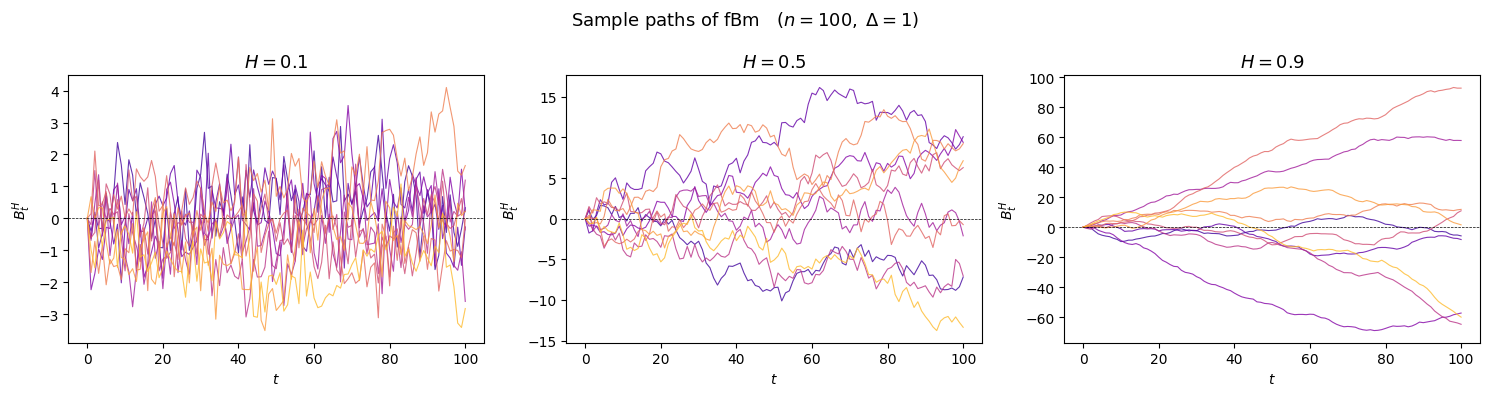

Done.


In [60]:
import matplotlib.pyplot as plt

n_plot, delta_plot, m_plot = 100, 1.0, 10
H_vals = [0.1, 0.5, 0.9]
t_plot = np.arange(n_plot + 1) * delta_plot
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colours = plt.cm.plasma(np.linspace(0.1, 0.85, m_plot))
 
for ax, H in zip(axes, H_vals):
    paths = fBm_sim(H=H, n=n_plot, delta=delta_plot, m=m_plot)
    for i, path in enumerate(paths):
        ax.plot(t_plot, path, lw=0.8, alpha=0.8, color=colours[i])
    ax.set_title(f'$H = {H}$', fontsize=13)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$B^H_t$')
    ax.axhline(0, color='k', lw=0.5, ls='--')
 
fig.suptitle(r'Sample paths of fBm   ($n = 100,\;\Delta = 1$)', fontsize=13)
plt.tight_layout()
plt.savefig('fBm_paths.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done.")